# Decision Tree

Here we will do not much but see and caculate the entropy, information gain see how D.T works and in next dataset and notebook we wil look overfittinng underfititng hyperparameters, libary to visualize the tree etc . n

In [122]:
import pandas as pd 
import numpy as np 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [123]:
data=pd.read_csv('/Users/bibekacharya/Documents/Documents/Machine_Learning/Machine Learning/Decision Tree/play_tennis.xls')
df=data.copy()
df

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [124]:
df.columns

Index(['  day', 'outlook', 'temp', 'humidity', 'wind', 'play'], dtype='object')

In [125]:
# Play is target col so lets first encode it 
df['play'].value_counts()

play
Yes    9
No     5
Name: count, dtype: int64

In [126]:
from sklearn.preprocessing import LabelEncoder
encode=LabelEncoder()
df['play']=encode.fit_transform(df['play'])
df['play']

0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: play, dtype: int64

In [127]:
df['play'].value_counts()

# yes is 1 . no is 0 

play
1    9
0    5
Name: count, dtype: int64

In [128]:
df

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,0
1,D2,Sunny,Hot,High,Strong,0
2,D3,Overcast,Hot,High,Weak,1
3,D4,Rain,Mild,High,Weak,1
4,D5,Rain,Cool,Normal,Weak,1
5,D6,Rain,Cool,Normal,Strong,0
6,D7,Overcast,Cool,Normal,Strong,1
7,D8,Sunny,Mild,High,Weak,0
8,D9,Sunny,Cool,Normal,Weak,1
9,D10,Rain,Mild,Normal,Weak,1


Decision Tree is nothign but programically set of nested if else conditions.. It splits based on certain attribute . 

Here to find the best attribute we use the information gain but before that we need entropy so lets calc it 

Entropy is the uncertanity, its like how uncertain the thign is ,, it may be also called the mesaure of disorder. 

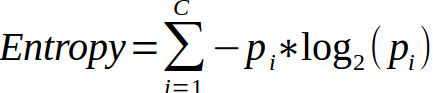

say you are calss techer and in class out of 10 all students passed then if asked will new student pass then ?/ your answer will be 100 percent yes so , whats the entropy , its 0 .. we are very certain that student will pass so the entropy is very low. 


now say 5 std passed 5 failed and we had to determine next student will pass or not then we dont konw we dont have enough knowlegde about either side so here entropy is high cuz we are uncertain whether the new student will pass or not 

In [129]:
df['play'].head(16)

0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: play, dtype: int64

In [130]:
# say our calss has 2 labels then entropy would be 

df[df['play']==0].count()

  day       5
outlook     5
temp        5
humidity    5
wind        5
play        5
dtype: int64

In [131]:
df[df['play']==1].count()

  day       9
outlook     9
temp        9
humidity    9
wind        9
play        9
dtype: int64

In [132]:
# from above we got probab 

probab_1_yes=9/14
probab_0_no=5/14

def entropy(probab_1_yes,probab_0_no):
    entropy_=-probab_1_yes*np.log2(probab_1_yes) - probab_0_no*np.log2(probab_0_no)
    print(entropy_)

entropy(9/14,5/14)

0.9402859586706311


> entropy(h)=====>.  0<h<1


Since this is close to the maximum entropy (1) for a binary classification problem, the class labels at the root are quite mixed.
So before looking at any features (like Outlook, Temperature, Humidity, or Wind), if someone asks:
"Will the next person play tennis?"
your answer is:
We cannot predict with high confidence because the dataset still contains a lot of uncertainty.

### Information Gain. 

Information Gain is the metric used to train decison tree. this metric measure the quality of split . It is based on decrease of entropy after dataset is split in an attribute 

Construction of decision tree is all about finding the attriubute that returns the highest informatin gain 

##### Information Gain = Entropy(parent)- wt.avg *Entropy(children)

so what we do is using informaitn gain we split a attribute/col find the entropy and whicher ever attribte has less entropy we split the data basedon that then again cals and attribure which gives best informatin gain(less entropy) we again split the data on that ... 


we have data as : 
day 	outlook	 temp	humidity	wind	play

here first we calc the entropy of parent which is play... after that we take one col say we took 

outloook: 
then inside outlook we have category like Sunny, overcast and rainy 

for sunny, 
E(s)= -probab_yes *log2(probabyes)- probab_no*log2(probab_no )

like wise we do for overcast and rainyl as well then we calc the weighted avg * entropy(child)(which was outlook)
 

wt.avg*enrtopy child = 5/14*entropy_sunny + 4/14*entropy_overcase +5/14 * entropy_rainly 

here 5/14, 4/14 etc are rows lie for sunny 5 rows of out of all outlook were tehre for overcast 4 rows were there 


then at last for outlook col we calc 

entropy_parent(yes/n0)- wt.avg*entopy child 


>> choose the attribute with the lowest weighted child entropy (or highest information gain).

>>> then, 

Then compute information gain using only the remaining attributes
Temperature
Humidity
Wind
Choose the best one.
Repeat.

### Gini impurity 

we learnt above about entropy , like entropy gini is also a measure to know the uncertanity its just that it is the default value used by sklearn library. 

its just in entropy we had to calc log so it was bit slower than gini 


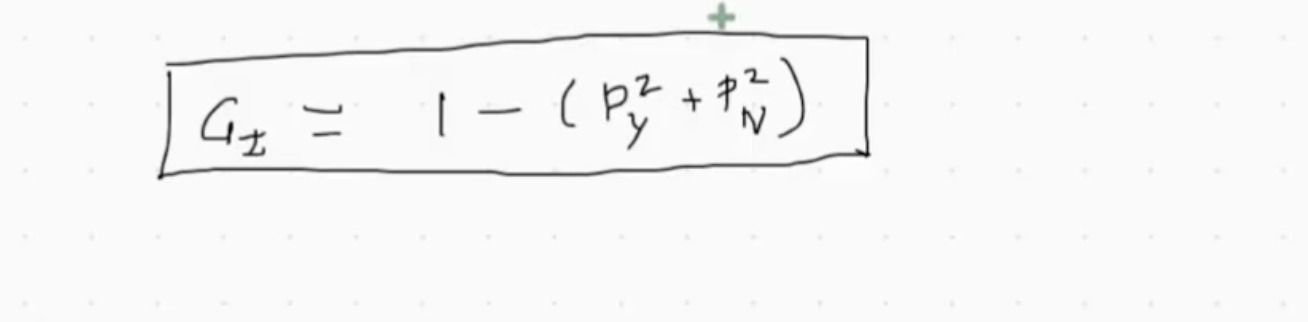


In [ ]:
# now lets tain model 

X=df.drop(columns=['play','  day'],axis=1)
y=df['play']

#

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [135]:
X_train

,outlook,temp,humidity,wind
8,Sunny,Cool,Normal,Weak
2,Overcast,Hot,High,Weak
1,Sunny,Hot,High,Strong
13,Rain,Mild,High,Strong
4,Rain,Cool,Normal,Weak
7,Sunny,Mild,High,Weak
10,Sunny,Mild,Normal,Strong
3,Rain,Mild,High,Weak
6,Overcast,Cool,Normal,Strong


In [136]:
#first encode the data , scalig not req for this 
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
encode=OneHotEncoder()
X_train=encode.fit_transform(X_train)
X_test=encode.transform(X_test)

In [137]:
tree=DecisionTreeClassifier(criterion='entropy') # if we just leave if default then 'Gini' used 
tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [138]:
ypred=tree.predict(X_test)
accuracy_score(y_test,ypred)


0.6

In [ ]:
tree1=DecisionTreeClassifier(criterion='gini') #default one  
tree1.fit(X_train,y_train)
ypred2=tree1.predict(X_test)
accuracy_score(y_test,ypred2)


0.6

In [147]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree, X_train, y_train, cv=5)

print(scores)
print(scores.mean())

[0.5 0.5 0.5 0.5 1. ]
0.6


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


In [142]:
print("Actual:", y_test.values)
print("Predicted:", ypred)

Actual: [1 1 0 1 0]
Predicted: [1 0 0 1 1]


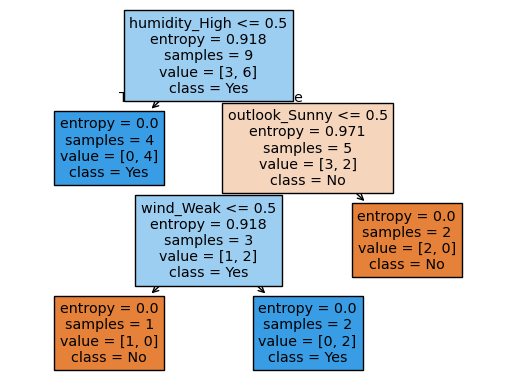

In [144]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure()
plot_tree(
    tree,
    feature_names=encode.get_feature_names_out(),
    class_names=['No', 'Yes'],
    filled=True
)
plt.show()

## 🚀 How does `DecisionTreeClassifier` use Information Gain?

Earlier, we manually learned how to build a Decision Tree:

### Does Scikit-Learn perform these calculations automatically?

**Yes.**

When we create a decision tree using Scikit-Learn,

```python
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion="entropy")
tree.fit(X_train, y_train)
```

we never manually calculate entropy or Information Gain.

Internally, `DecisionTreeClassifier` performs the complete algorithm:

- Computes the entropy of the current node.
- Evaluates every available feature.
- Calculates the weighted entropy after splitting on each feature.
- Computes the Information Gain for every possible split.
- Selects the split with the **maximum Information Gain**.
- Recursively repeats the same process for each child node until the stopping criteria are met (pure node, maximum depth, minimum samples, etc.).

This process is completely hidden from the user.

---

### Analogy with Gradient Descent

This is very similar to how Scikit-Learn handles optimization in other machine learning algorithms.

For example, when using:

```python
from sklearn.linear_model import SGDClassifier

model = SGDClassifier()
model.fit(X_train, y_train)
```

> **In summary:** Just as `SGDClassifier` internally performs Gradient Descent, `DecisionTreeClassifier` internally performs Entropy/Gini calculations and Information Gain-based splitting to construct the optimal decision tree.

This much in this dataset now we still haev to see overfitting underfitting and how to overcome themn using hyper parameters . we will use a bigger datset and see 

In [ ]:
# go to imp_second.ipnb now !!